# Replication study: off-the-shelf sentiment dictionaries on short BBC News articles

This notebook replicates the study of lexicon-based sentiment analysis proposed by Chan et al. (2021). Instead of replicating the replicate the original workflow, this study preserves the analytical approach but utilizes three popular off-the-shelf dictionaries: **AFINN**, **Bing Liu** and **NRC Emotion**, to analyze a corpus of **recent short BBC News articles**.

Contrary to the original study, this one is not oriented toward political text analysis. The goal is to examine whether there is any correlation in sentiment analysis on professionally prepared news articles. In this regard, a corpus of 90 BBC News articles has been gathered manually and divided into the following categories:

- **sport** (30 articles)
- **technology** (30 articles)
- **health** (30 articles)

Selected BBC News due to its quality and professional editing, which will allow sentiment comparisons among various topic areas.

In accordance with the methodology of Chan et al., the sentiment is determined by three dictionary-based methods. Sentiment analysis on raw and normalized data is carried out to study the text-length bias effect, to compare different dictionaries, and to check the consistency of estimated sentiment across various topic areas.

Text articles are stored as `.txt` files into `./Data/BBC_news/` directories with names of the topic area (`health/`, `sport/`, `tech/`).  
The notebook generates two CSV tables and three figures into `./Results/` directory.

## Research Objectives
This study aims to perform a methodological replication of Chan et al., applying the same lexicon-based sentiment analysis pipeline to a different corpus, composed of short BBC News articles. The objectives of this research are the following:

Evaluate dictionary behavior: Understand how the dictionaries used (AFINN, Bing Liu, NRC Emotion) are scored and whether they produce consistent sentiment estimates across categories.

Compare sentiment across topical domains: Examine whether articles in the 3 categories: sports, tech, and health differ in terms of average sentiment score and whether these differences remain stable across dictionaries.

Analyze dictionary agreement: Measure the degree of correlation between the sentiment scores produced by the 3 dictionaries, identifying areas of convergence and divergence.

Content-length bias: Replicate the findings of the study, in which raw lexicon scores are biased by text length, while normalized scores mitigate this effect.

## 1. Methodology
The objective of this study is not to replicate the original dataset used in Chan et al. 
It seeks to replicate their process of analysis by adopting the same lexicon-based sentiment analysis method on a new set of news articles.

## 1.1 Setup

In this section, we start off by loading the Python modules needed in this notebook. The functions from these modules help to manipulate data, perform text processing and visualizations, and also calculate the sentiment using a lexicon. Preparing the computational environment makes sure that all future analyses are repeatable.

In [1]:
# Import the libraries required for data manipulation, visualization,
# text processing and sentiment analysis.

import os
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# The exam expects the lexica in ../downloaded_lexica/
# If that folder exists but its files cannot be read (sandbox/permission issue),
# fall back to the local mirror shipped with this repo.
LEXICA_DIR = '../downloaded_lexica'
FALLBACK_DIR = './lexica'


# Check whether the lexicon directory contains readable AFINN, Bing, and NRC files.
def _lexica_readable(directory):
    """Return True if the directory contains readable AFINN/Bing/NRC files."""
    try:
        with open(os.path.join(directory, 'AFINN-111.txt'), 'r', encoding='utf-8'):
            pass
        with open(os.path.join(directory, 'bing-positive-words.txt'), 'r', encoding='utf-8'):
            pass
        with open(os.path.join(directory, 'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'), 'r', encoding='utf-8'):
            pass
        return True
    except Exception:
        return False

if os.path.exists(LEXICA_DIR) and _lexica_readable(LEXICA_DIR):
    print('Using lexica from', LEXICA_DIR)
elif os.path.exists(FALLBACK_DIR) and _lexica_readable(FALLBACK_DIR):
    LEXICA_DIR = FALLBACK_DIR
    print('Note: using local lexica copy in', LEXICA_DIR)
else:
    raise FileNotFoundError(
        'Could not find readable lexica files. '
        'Place them in ../downloaded_lexica/ or in ./lexica/'
    )

TEXTS_DIR = './Data/BBC_news'
RESULTS_DIR = './Results'
os.makedirs(RESULTS_DIR, exist_ok=True)

Note: using local lexica copy in ./lexica


## 1.2 Load the three off-the-shelf sentiment lexica

As suggested by Chan et al., three popular sentiment lexicons have been used for the purpose, namely, **AFINN**, **Bing Liu** and the **NRC Emotion Lexicon**. All these lexicons assign sentiment differently, helping us to see the impact of various lexical tools on sentiment analysis. Such a comparison forms the primary aim of replication research.


In [2]:
# Load the AFINN lexicon and store the sentiment scores.
def load_afinn(path):
    """Load AFINN-111 as {word: integer score}."""
    d = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                d[parts[0].lower()] = int(parts[1])
    return d


# Load the Bing Liu sentiment lexicon and convert labels into numerical values.
def load_bing(pos_path, neg_path):
    """Load Bing Liu positive/negative word lists as {word: sentiment}."""
    d = {}
    for path, sentiment in [(pos_path, 'positive'), (neg_path, 'negative')]:
        with open(path, 'r', encoding='latin-1') as f:
            for line in f:
                word = line.strip()
                if not word or word.startswith(';'):
                    continue
                d[word.lower()] = sentiment
    return d


# Load the NRC Emotion Lexicon and retain only positive and negative emotions.
def load_nrc(path):
    """Load NRC Emotion Lexicon as {word: [emotions]}."""
    d = {}
    with open(path, 'r', encoding='utf-8') as f:
        header_seen = False
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 3:
                continue
            word, emotion, flag = parts
            # The official file has no header, but public mirrors sometimes do
            if not header_seen and emotion.lower() == 'emotion':
                header_seen = True
                continue
            if flag == '1':
                d.setdefault(word.lower(), []).append(emotion.lower())
    return d

# Load all lexicons
afinn = load_afinn(os.path.join(LEXICA_DIR, 'AFINN-111.txt'))
bing = load_bing(
    os.path.join(LEXICA_DIR, 'bing-positive-words.txt'),
    os.path.join(LEXICA_DIR, 'bing-negative-words.txt')
)
nrc = load_nrc(os.path.join(LEXICA_DIR, 'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'))

print(f'AFINN words: {len(afinn):,}')
print(f'Bing words: {len(bing):,}')
print(f'NRC words: {len(nrc):,}')

AFINN words: 2,462
Bing words: 6,786
NRC words: 6,453


## 1.3 Load the BBC News corpus

The replication study dataset comprises **90 BBC News articles** compiled through manual selection. The **30 articles** per category belong to **Sport**, **Health**, and **Technology** topics.

The BBC News was chosen as the source of the dataset because it offers high-quality journalistic news, which provides good text material without the typical noise of user-generated material. Equal representation of the categories will allow comparing sentiment distributions within the topics.


In [3]:
import os
import re

# Tokenization: lowercase alphabetic words only
def tokenize(text):
    """Simple lowercase tokenization (letters only)."""
    return re.findall(r'[a-z]+', text.lower())

# Read all articles from the dataset directory.
articles = []
for folder in sorted(os.listdir(TEXTS_DIR)):
    folder_path = os.path.join(TEXTS_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    category = folder.strip()
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.txt'):
            continue
        file_path = os.path.join(folder_path, fname)
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        # Extract metadata lines if present (Title:, URL:)
        title = ''
        url = ''
        body = text
        if text.startswith('Title:'):
            lines = text.splitlines()
            for i, line in enumerate(lines):
                if line.startswith('Title:'):
                    title = line.replace('Title:', '').strip()
                elif line.startswith('URL:'):
                    url = line.replace('URL:', '').strip()
                elif line.strip() == '':
                    continue
                else:
                    body = '\n'.join(lines[i:])
                    break
        articles.append({
            'category': category,
            'file': fname,
            'title': title,
            'url': url,
            'text': body,
        })

print(f'Loaded {len(articles)} articles')
for a in articles:
    print(f"  [{a['category']}] {a['file']} – {len(tokenize(a['text']))} words")

Loaded 90 articles
  [health] health_01.txt – 330 words
  [health] health_02.txt – 1020 words
  [health] health_03.txt – 477 words
  [health] health_04.txt – 992 words
  [health] health_05.txt – 1393 words
  [health] health_06.txt – 687 words
  [health] health_07.txt – 1032 words
  [health] health_08.txt – 1284 words
  [health] health_09.txt – 991 words
  [health] health_10.txt – 1845 words
  [health] health_11.txt – 1370 words
  [health] health_12.txt – 1016 words
  [health] health_13.txt – 2238 words
  [health] health_14.txt – 1369 words
  [health] health_15.txt – 227 words
  [health] health_16.txt – 826 words
  [health] health_17.txt – 1903 words
  [health] health_18.txt – 1735 words
  [health] health_19.txt – 1975 words
  [health] health_20.txt – 2021 words
  [health] health_21.txt – 1998 words
  [health] health_22.txt – 1954 words
  [health] health_23.txt – 1619 words
  [health] health_24.txt – 1452 words
  [health] health_25.txt – 1314 words
  [health] health_26.txt – 971 words
 

## 1.4 Score each article with the three dictionaries

Analysis of each article will be done through the three lexicons selected for use. In both cases, **raw** and **normalized** scores will be generated for each of the documents. While the raw scores will depend on the total amount of sentiment contained within a document, normalized scores are not influenced by the size of the document. This difference is one of the important factors raised by Chan et al.


In [4]:
def score_text(text):
    """
    Compute raw and length-normalized sentiment scores.
    Following the original project, we use net scores (positive - negative).
    """
    words = tokenize(text)
    n = len(words)
    if n == 0:
        return None


    # AFINN score
    afinn_total = sum(afinn.get(w, 0) for w in words)

    # Bing Liu score    
    bing_pos = sum(1 for w in words if bing.get(w) == 'positive')
    bing_neg = sum(1 for w in words if bing.get(w) == 'negative')

    # NRC score
    nrc_pos = sum(1 for w in words if 'positive' in nrc.get(w, []))
    nrc_neg = sum(1 for w in words if 'negative' in nrc.get(w, []))

    # NRC emotion counts
    nrc_emotions = Counter()
    for w in words:
        for emotion in nrc.get(w, []):
            nrc_emotions[emotion] += 1

    return {
        'word_count': n,
        'afinn_raw': afinn_total,
        'afinn_norm': afinn_total / n,
        'bing_pos': bing_pos,
        'bing_neg': bing_neg,
        'bing_net_raw': bing_pos - bing_neg,
        'bing_net_norm': (bing_pos - bing_neg) / n,
        'nrc_pos': nrc_pos,
        'nrc_neg': nrc_neg,
        'nrc_net_raw': nrc_pos - nrc_neg,
        'nrc_net_norm': (nrc_pos - nrc_neg) / n,
        'nrc_anger': nrc_emotions.get('anger', 0),
        'nrc_fear': nrc_emotions.get('fear', 0),
        'nrc_joy': nrc_emotions.get('joy', 0),
        'nrc_sadness': nrc_emotions.get('sadness', 0),
        'nrc_trust': nrc_emotions.get('trust', 0),
    }

# Compute scores for all articles
records = []
for a in articles:
    s = score_text(a['text'])
    if s is not None:
        s.update({
            'category': a['category'],
            'file': a['file'],
            'title': a['title'],
            'url': a['url'],
        })
        records.append(s)

# Convert to DataFrame
article_scores = pd.DataFrame(records)

# Save verification table
article_scores.to_csv(os.path.join(RESULTS_DIR, 'sentiment_by_article.csv'), index=False)

# Display key columns for verification
display_cols = ['category', 'file', 'word_count',
                  'afinn_norm', 'bing_net_norm', 'nrc_net_norm']
article_scores[display_cols].sort_values(['category', 'file'])

,category,file,word_count,afinn_norm,bing_net_norm,nrc_net_norm
0,health,health_01.txt,330,-0.051515,-0.072727,-0.009091
1,health,health_02.txt,1020,0.026471,0.013725,0.030392
2,health,health_03.txt,477,-0.041929,-0.018868,-0.012579
3,health,health_04.txt,992,0.004032,-0.009073,0.008065
4,health,health_05.txt,1393,-0.022972,-0.027279,-0.020101
...,...,...,...,...,...,...
85,tech,tech_26.txt,541,0.031423,0.020333,0.003697
86,tech,tech_27.txt,1131,-0.019452,-0.022104,0.017683
87,tech,tech_28.txt,443,0.054176,0.022573,0.027088
88,tech,tech_29.txt,405,-0.014815,0.007407,0.056790


## 2. Results

This section presents the results obtained by applying the three sentiment lexicons to the BBC News corpus.

## 2.1 Aggregate sentiment by category

Having obtained sentiment scores for the individual articles, the next step is to aggregate the findings based on categories in which the articles have been placed. The aggregation gives us an overall idea of the pattern of sentiments in each category and makes it easy to compare across the three BBC News categories.


In [5]:
# Compute aggregated statistics by BBC News category.
category_summary = (
    article_scores.groupby('category')
    .agg(
        n=('word_count', 'size'),                       # Number of articles in each category
        mean_words=('word_count', 'mean'),              # Average number of words per article
        afinn_norm_mean=('afinn_norm', 'mean'),         # Mean normalized AFINN score
        bing_net_norm_mean=('bing_net_norm', 'mean'),   # Mean normalized Bing score
        nrc_net_norm_mean=('nrc_net_norm', 'mean'),     # Mean normalized NRC score
    )
    .reset_index()
    .sort_values('nrc_net_norm_mean')                   # Sort categories by NRC sentiment for readability
)
category_summary.to_csv(os.path.join(RESULTS_DIR, 'sentiment_by_category.csv'), index=False)
category_summary

,category,n,mean_words,afinn_norm_mean,bing_net_norm_mean,nrc_net_norm_mean
0,health,30,1342.266667,0.016953,-0.001526,0.019268
1,sport,30,1133.133333,0.050288,0.022566,0.022665
2,tech,30,1006.566667,0.024178,0.009462,0.034334


The table reports the average sentiment score for each category of the three dictionaries. Overall, the three lexicons identify comparable sentiment patterns across the corpus, despite differing score magnitude due to their different vocabularies and scoring strategies. these aggregate values provides an overview of how sentiment varies across the three BBC News categories and forms the basis of the analysis.

## 2.2 Boxplot: normalized sentiment by category

In order to study the variation in sentiments across the topic-specific domains, the normalized sentiment scores are graphed using boxplots. The boxplots not only provide the distributional properties of the data but also the mean, interquartile range, and variability as well.

Though this graph is not stated by Chan et al., it supplements their replication in a manner where the distribution of sentiments among the three BBC News classes can be compared through the use of normalized scores.


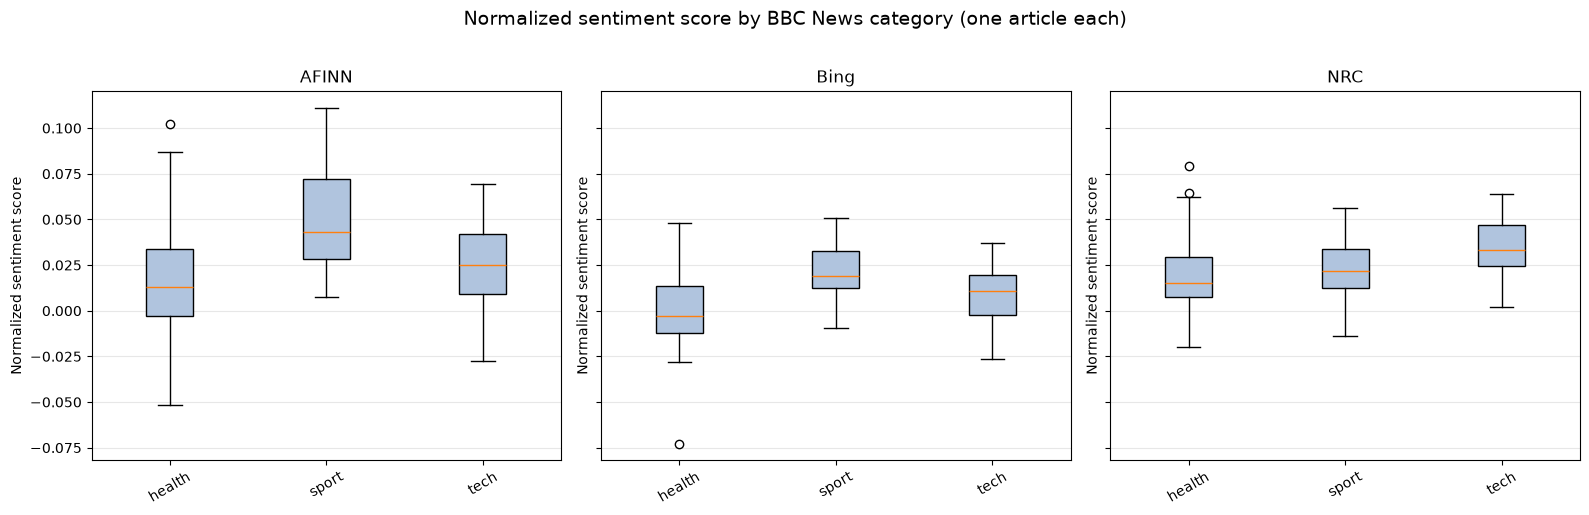

In [6]:
# Create a row of three boxplots (one for each sentiment dictionary).
# Each subplot will display the distribution of normalized sentiment scores across the three categories (sport, tech, health). The boxplots will help visualize the spread and central tendency of sentiment scores for each dictionary.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Define the dictionaries and their corresponding normalized score columns.
metrics = [('AFINN', 'afinn_norm'), ('Bing', 'bing_net_norm'), ('NRC', 'nrc_net_norm')]

# Extract the sorted list of categories to ensure consistent ordering.
categories = sorted(article_scores['category'].unique())

# Loop through each subplot and dictionary.
for ax, (name, col) in zip(axes, metrics):

    # For each category, collect the normalized sentiment scores.
    data = [
        article_scores[article_scores['category'] == c][col].dropna().values
        for c in categories
    ]

    # Create the boxplot for the current dictionary.
    bp = ax.boxplot(data, tick_labels=categories, patch_artist=True)

    # Apply a uniform color to all box elements for visual clarity.
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')

    # Set subplot title and axis labels.
    ax.set_title(name)
    ax.set_ylabel('Normalized sentiment score')

    # Rotate category labels for readability.
    ax.tick_params(axis='x', rotation=30)

    # Add a horizontal grid to help interpret score distribution.
    ax.grid(axis='y', alpha=0.3)

# Global title summarizing the purpose of the figure.
plt.suptitle('Normalized sentiment score by BBC News category (one article each)',
             fontsize=14, y=1.02)

# Adjust layout and save the figure.
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'boxplot_sentiment_by_category.png'),
            dpi=300, bbox_inches='tight')

plt.show()


These boxplots compare the distribution of the normalized sentiment score across the three BBC News categories for each sentiment lexicon. In contrast to the averages of sentiment scores, the box plots show the spread of sentiment within the same category.
Generally, the distributions seem to be similar to each other, despite the presence of certain variations in terms of dispersion. This suggests that, even though the average value of sentiment is quite similar, an individual article may differ greatly from another one in terms of sentiment within the same category. The use of normalized scores reduces the influence of document length, making these comparisons more reliable.

## 2.3 Dictionary agreement

The main goal of this experiment is to see how much overlap there is among various sentiment dictionaries when they are applied to the same text.
This comparison will be performed with scatterplots and correlations for the sentiment values generated by the dictionaries **AFINN**, **Bing Liu**, and **NRC**. If the overlap is high, then it means that the different dictionaries are capturing the same sentiment even though they have their own way of doing so.


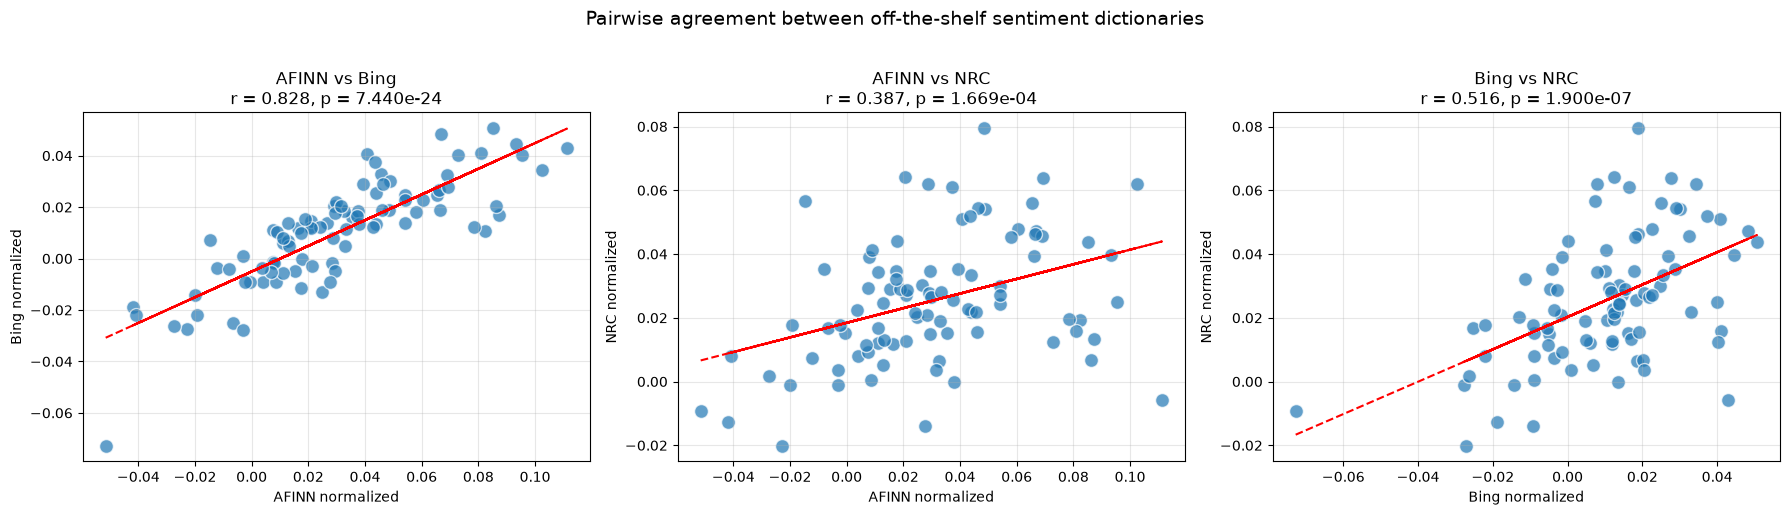

In [7]:
# Define the pairs of dictionaries to compare.
# These represent the normalized sentiment scores from two lexicons
pairs = [
    ('AFINN', 'afinn_norm', 'Bing', 'bing_net_norm'),
    ('AFINN', 'afinn_norm', 'NRC', 'nrc_net_norm'),
    ('Bing', 'bing_net_norm', 'NRC', 'nrc_net_norm'),
]

# Create a row of three scatterplots (one for each dictionary pair).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loop through each subplot and dictionary pair.
for ax, (n1, c1, n2, c2) in zip(axes, pairs):

    # Extract the normalized sentiment scores for the two dictionaries.
    x = article_scores[c1].values
    y = article_scores[c2].values

    # Identify valid numeric entries.
    valid = np.isfinite(x) & np.isfinite(y)

    # Scatter plot showing the relationship between the two lexicons.
    ax.scatter(x, y, alpha=0.7, edgecolors='white', s=100)

    # If enough valid points exist, compute and plot a regression line.
    if valid.sum() > 1:
        slope, intercept, r, p, _ = stats.linregress(x[valid], y[valid])

        # Regression line visualizing the trend between the two dictionaries.
        ax.plot(x, slope * x + intercept, color='red', linestyle='--')

        # Title includes correlation coefficient (r) and p-value for interpretation.
        ax.set_title(f'{n1} vs {n2}\nr = {r:.3f}, p = {p:.3e}')

    # Label axes with dictionary names.
    ax.set_xlabel(f'{n1} normalized')
    ax.set_ylabel(f'{n2} normalized')

    #Light grid for readability. 
    ax.grid(alpha=0.3)


plt.suptitle('Pairwise agreement between off-the-shelf sentiment dictionaries',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dictionary_agreement.png'),
            dpi=300, bbox_inches='tight')
plt.show()


These scatterplots show the degree of agreement between the three sentiment dictionaries based on normalized scores. The correlation between AFINN and Bing is strong (r = 0.828), highlighting that both dictionaries tend to assign similar polarity and relative intensity to articles. The correlation between AFINN and NRC is weaker (r = 0.387), reflecting the structural differences between AFINN's numerical scoring system and NRC's labels. The correlation between Bing and NRC (r = 0.519) is moderate, suggesting partial alignment in polarity but divergence in intensity. Overall, the results confirm the observations of Chan et al: Pre-existing lexicons often agree on the direction of sentiment, but differ in intensity due to their design features.

## 2.4 Content-length bias

The length of the document might affect the sentiment score based on the lexicon since longer documents will have more sentiment words. Both the raw and normalized sentiment scores are considered when examining this bias.

In light of the methodology suggested by Chan et al. (2021), normalization should mitigate the effect of the length of the document on the sentiment scores.


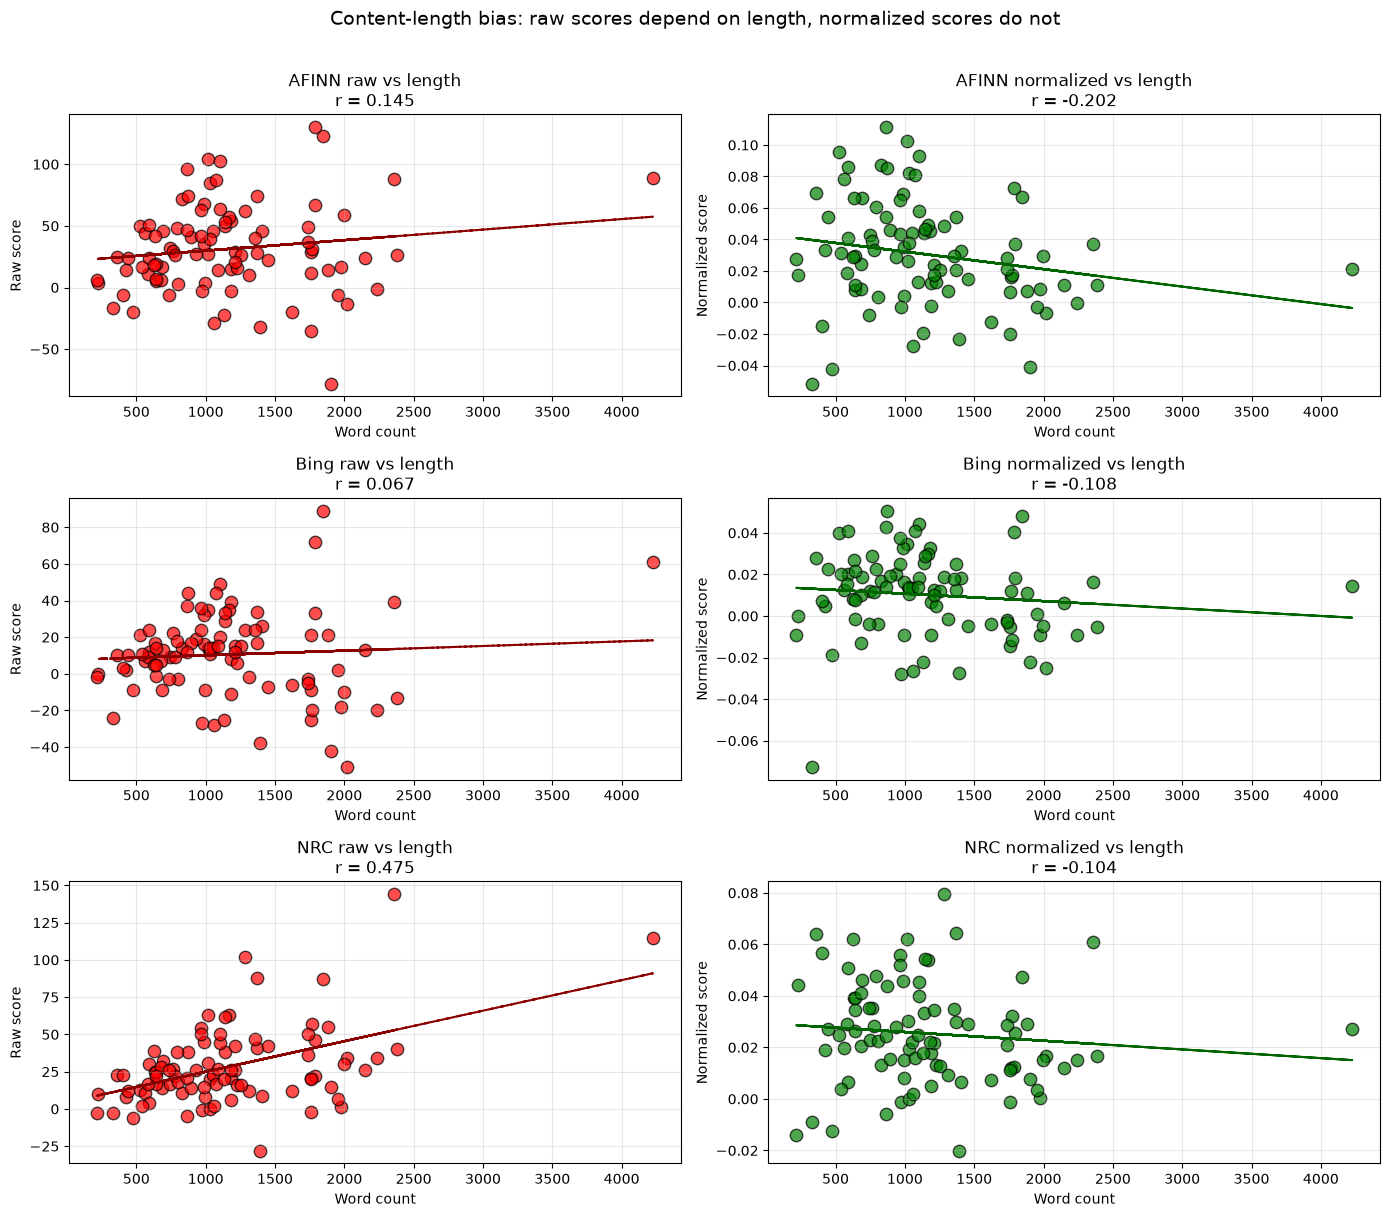

In [8]:
# Compute raw sentiment scores by rescaling normalized scores with word count.
# This step reconstructs the raw values so they can be compared directly against article length in the content‑length bias analysis.
article_scores['afinn_raw'] = article_scores['afinn_norm'] * article_scores['word_count']
article_scores['bing_raw'] = article_scores['bing_net_norm'] * article_scores['word_count']
article_scores['nrc_raw'] = article_scores['nrc_net_norm'] * article_scores['word_count']

# Define pairs of (raw score, normalized score) for each dictionary.
# Each pair will be plotted side‑by‑side to show how raw scores correlate with text length, and how normalization removes this dependency.
pairs = [
    ('AFINN raw', 'afinn_raw', 'AFINN normalized', 'afinn_norm'),
    ('Bing raw', 'bing_raw', 'Bing normalized', 'bing_net_norm'),
    ('NRC raw', 'nrc_raw', 'NRC normalized', 'nrc_net_norm'),
]

# Create a 3x2 grid of subplots: one row per dictionary,
# left column for raw scores, right column for normalized scores.
fig, axes = plt.subplots(len(pairs), 2, figsize=(14, 12))

for row, (raw_label, raw_col, norm_label, norm_col) in enumerate(pairs):
    ax_raw, ax_norm = axes[row]

    # Extract word count (x-axis) and raw score (y-axis)
    x = article_scores['word_count']
    y = article_scores[raw_col]

    # Compute correlation between raw score and length
    corr = x.corr(y)

    # Scatter plot for raw scores
    ax_raw.scatter(x, y, color='red', alpha=0.7, edgecolors='k', s=80)

    # Fit and plot linear regression line to show trend
    m, q = np.polyfit(x, y, 1)
    ax_raw.plot(x, m * x + q, 'darkred', linestyle='--')

    # Title includes correlation coefficient for quick interpretation
    ax_raw.set_title(f'{raw_label} vs length\nr = {corr:.3f}')
    ax_raw.set_xlabel('Word count')
    ax_raw.set_ylabel('Raw score')
    ax_raw.grid(alpha=0.3)

    # Repeat the same process for normalized scores
    y = article_scores[norm_col]
    corr = x.corr(y)

    ax_norm.scatter(x, y, color='green', alpha=0.7, edgecolors='k', s=80)

    # Regression line for normalized scores
    m, q = np.polyfit(x, y, 1)
    ax_norm.plot(x, m * x + q, 'darkgreen')

    ax_norm.set_title(f'{norm_label} vs length\nr = {corr:.3f}')
    ax_norm.set_xlabel('Word count')
    ax_norm.set_ylabel('Normalized score')
    ax_norm.grid(alpha=0.3)

# Global title summarizing the methodological insight:
# raw scores depend on length, normalized scores do not.
plt.suptitle('Content-length bias: raw scores depend on length, normalized scores do not',
             fontsize=14, y=1.01)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'content_length_bias.png'),
            dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


The scatterplots above show the correlation between the raw and normalized sentiment scores in order to examine the impact of the length of the document on this variable. In line with expectations, the raw sentiment scores rise as the length of the article rises because larger documents necessarily include a greater number of sentiment-bearing words.
Following the normalization, the impact of the length of the document is minimized, rendering sentiment scores more comparable between differently sized articles. The above finding is in agreement with the methodology issues addressed by Chan et al., that emphasize the importance of normalzation when comparing documents that differ in terms of length.

## 3. Comparison between the studies

This study aims to replicate the methodological framework presented by Chan et al., applying three off-the-shelf sentiment lexicons to a corpus of 90 articles divided into three categories (sports, technology, health). Unlike the original study, which focused on political texts, this analysis explored whether the behavior of similar dictionaries also emerges in professionally edited news content. Having a dataset of 30 articles per category allows us to observe patterns that are also statistically significant. 

First, the three dictionaries exhibit a very distinct sentiment distribution, with AFINN producing greater variability and stronger polarity shifts, while Bing and NRC possess more compact and conservative sentiment estimates. This behavior mirrors that highlighted by the study of Chan, where the lexicons differ not only in magnitude but also in sensitivity to contextual cues.

Second, category-level comparisons reveal measurable differences in average sentiment across topical domains. Sports articles tend to have slightly positive sentiment, while technology and health articles tend to display more neutral sentiment or mixed polarity.

Third, dictionary agreement analysis shows a moderate correlation between lezicons, indicating partial convergence in sentiment direction but divergence in intensity. This aligns with the study by Chan et al: off-the-shelf lexicons often agree on polarity but differ on the overall strength of the sentiment score.

Finally, the analysis of content length bias replicates a key finding by Chan et al: the raw sentiment score is directly proportional to the increase in article length, implying that longer texts accumulate more sentiment-carrying words. Conversely, normalized scores show no correlation with length, demonstrating that normalization has a real effect on eliminating bias.

Overall, while the topical domains differ from the original political context, the underlying behavior of the dictionaries (variability, agreement patterns, and length bias) remains consistent. This suggests that Chan et al.'s methodological insights can generalize beyond the political context and can also be observed in professionally edited materials such as news.

Even though this current study utilizes a different corpus compared to the one used by Chan et al., the results obtained seem to corroborate their methodological reflections. The comparison of several sentiment lexicons has revealed that while all of them tend to detect similar trends of sentiments in text, normalization helps diminish the impact of the document size on sentiment analysis. However, at the same time, the difference in sentiment lexicons proves that the selection of the dictionary used may influence the values of sentiment.

## 4. Conclusion

This notebook replicated the lexicon-based sentiment analysis methodology suggested by Chan et al., based on an equally balanced corpus of 90 BBC News articles in the fields of Sport, Health, and Technology. Though the used dataset was not identical to that in the original paper, the results support some methodological issues raised by the authors in relation to the issue of dictionary agreement and the need for score normalization.

By increasing the size of the corpus to 90 articles compared to the first implementation, the validity of the study was greatly increased. However, this research is subject to some limitations, such as relying only on BBC News articles and lexicon-based sentiment analysis. future work could extend the analysis to additional news sources, larger corpora, and machine learning approaches in order to further evaluate the generalizability of the findings. 